NPL - Url Spam Detection

In [4]:
import pandas as pd
import regex as re 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from wordcloud import WordCloud 
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import accuracy_score
from pickle import dump
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/NLP-project-tutorial/main/url_spam.csv")
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [6]:
df["is_spam"] = df["is_spam"].apply(lambda x: 1 if x else 0).astype(int)
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1


In [7]:
df.shape

(2999, 2)

In [8]:
df = df.drop_duplicates()
df = df.reset_index(inplace = False, drop = True)
df.shape

(2369, 2)

In [11]:
print(f"Clean Mail: {len(df.loc[df.is_spam == 0])}")
print(f"Mail Spam: {len(df.loc[df.is_spam == 1])}")

Clean Mail: 2125
Mail Spam: 244


In [13]:
def preprocess_text(text):
    text = re.sub(r'[^a-z ]', " ", text)
    
    text = re.sub(r'\s+[a-zA-Z]\s+', " ", text)
    text = re.sub(r'\^[a-zA-Z]\s+', " ", text)

    text = re.sub(r'\s+', " ", text.lower())

    text = re.sub("&lt;/?.*?&gt;"," &lt;&gt; ", text)

    return text.split()

df["url"] = df["url"].apply(preprocess_text)
df.head()

,url,is_spam
0,"[https, briefingday, us, list, manage, com, un...",1
1,"[https, www, hvper, com]",1
2,"[https, briefingday, com, v, i]",1
3,"[https, briefingday, com, m, commentform]",0
4,"[https, briefingday, com, fan]",1


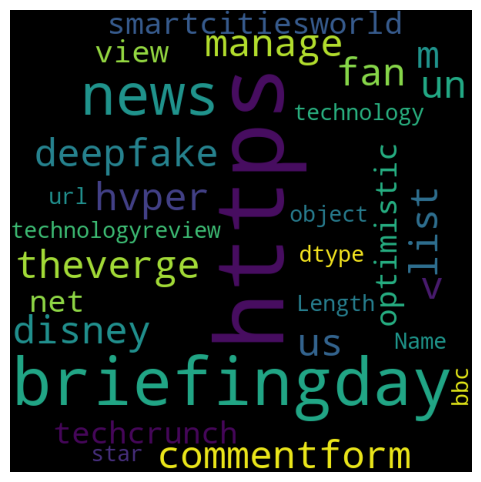

In [19]:
wordcloud = WordCloud(width = 600, height = 600, background_color = "black", max_words = 10000, min_font_size = 15, random_state = 25)\
    .generate(str(df["url"]))

fig = plt.figure(figsize = (6, 6), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [20]:
tokens_enum = df["url"]
tokens_enum = [" ".join(tokens) for tokens in tokens_enum]

vectorizer = TfidfVectorizer(max_features = 5000, max_df = 0.8, min_df = 5)
X = vectorizer.fit_transform(tokens_enum).toarray()
y = df["is_spam"]

X[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 691))

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

SVC MODEL

In [23]:
model = SVC(kernel = "linear", random_state = 42)
model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [24]:
y_test_pred = model.predict(X_test)
y_test_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

MODEL OPTIMIZATION

In [25]:
hyperparams = {
    "C": randint(0.0, 1000),
    "kernel": ["linear", "poly", "rbf", "sigmoid", "precomputed’"],
    "degree": randint(1, 8),
    "gamma": ["scale", "auto"]
}

In [26]:
random_search = RandomizedSearchCV(
    model,
    hyperparams,
    scoring='accuracy',
    cv=5,       
    n_jobs=1,  
    random_state=42
)
random_search

RandomizedSearchCV(cv=5, estimator=SVC(kernel='linear', random_state=42),
                   n_jobs=1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x72796c1548e0>,
                                        'degree': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x72796c155060>,
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid', 'precomputed’']},
                   random_state=42, scoring='accuracy')

In [27]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVC(kernel='linear', random_state=42),
                   n_jobs=1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x72796c1548e0>,
                                        'degree': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x72796c155060>,
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid', 'precomputed’']},
                   random_state=42, scoring='accuracy')

In [29]:
print("Best hyperparameters:", random_search.best_params_)

Best hyperparameters: {'C': 560, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}


In [30]:
opt_model = SVC(C = 560, degree = 3, gamma = "scale", kernel = "poly", random_state = 42)
opt_model.fit(X_train, y_train)
y_pred = opt_model.predict(X_test)
accuracy_score(y_test, y_test_pred)

0.959915611814346

In [31]:
dump(model, open("../models/svm_classifier_C:560_degr:3_gam:scale_kern:poly_random:42.sav", "wb"))